In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.models import * 
from tensorflow.keras.preprocessing import image

In [ ]:
train_datagen = image.ImageDataGenerator(
    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.1,
    height_shift_range=0.1
)
test_datagen= image.ImageDataGenerator(    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.1,
    height_shift_range=0.1)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/train',
    target_size = (224,224),
    batch_size = 8,
    class_mode = 'categorical')
test_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/test',
    target_size = (224,224),
    batch_size = 8,
    class_mode = 'categorical')
validation_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/valid',
    target_size = (224,224),
    batch_size = 8,
    shuffle=True,
    class_mode = 'categorical')

Found 613 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Found 91 images belonging to 4 classes.


In [ ]:
base_model = tf.keras.applications.MobileNetV2(weights='imagenet', input_shape=(224,224,3), include_top=False)

for layer in base_model.layers:
    layer.trainable=True
model = Sequential()
model.add(base_model)
model.add(GaussianNoise(0.25))
model.add(GlobalAveragePooling2D())
model.add(Dense(1024,activation='relu'))
model.add(BatchNormalization())
model.add(GaussianNoise(0.25))
model.add(Dropout(0.25))
model.add(Dense(4, activation='sigmoid'))
model.summary()

9406464/9406464 [==============================] - 0s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 gaussian_noise (GaussianNoi  (None, 7, 7, 1280)       0         
 se)                                                             
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1024)              1311744   
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              metrics=['accuracy','AUC','Precision','Recall'])

In [ ]:
from keras.callbacks import EarlyStopping
es=EarlyStopping(monitor='val_loss',patience=3)
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    steps_per_epoch= 75
    )

Epoch 1/100
75/75 [==============================] - 175s 2s/step - loss: 1.8308 - accuracy: 0.3199 - auc: 0.5742 - precision: 0.2899 - recall: 0.5846 - val_loss: 1.4680 - val_accuracy: 0.2637 - val_auc: 0.5580 - val_precision: 0.2605 - val_recall: 0.3407
Epoch 2/100
75/75 [==============================] - 14s 187ms/step - loss: 1.4816 - accuracy: 0.4372 - auc: 0.6674 - precision: 0.3409 - recall: 0.6750 - val_loss: 1.5669 - val_accuracy: 0.3516 - val_auc: 0.5693 - val_precision: 0.3178 - val_recall: 0.4505
Epoch 3/100
75/75 [==============================] - 12s 159ms/step - loss: 1.3310 - accuracy: 0.4807 - auc: 0.7162 - precision: 0.3621 - recall: 0.6951 - val_loss: 1.7794 - val_accuracy: 0.3297 - val_auc: 0.5622 - val_precision: 0.2821 - val_recall: 0.4835
Epoch 4/100
75/75 [==============================] - 12s 160ms/step - loss: 1.3411 - accuracy: 0.5150 - auc: 0.7289 - precision: 0.3775 - recall: 0.7450 - val_loss: 1.9326 - val_accuracy: 0.3736 - val_auc: 0.5866 - val_precision

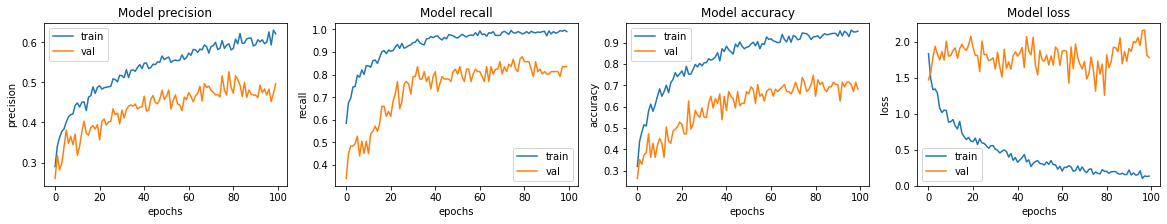

In [ ]:
fig,ax=plt.subplots(1,4,figsize=(20,3))
ax=ax.ravel()
for i,met in enumerate(['precision','recall','accuracy','loss']):
  ax[i].plot(history.history[met])
  ax[i].plot(history.history['val_'+met])
  ax[i].set_title('Model {}'.format(met))
  ax[i].set_xlabel('epochs')
  ax[i].set_ylabel(met)
  ax[i].legend(['train', 'val'])

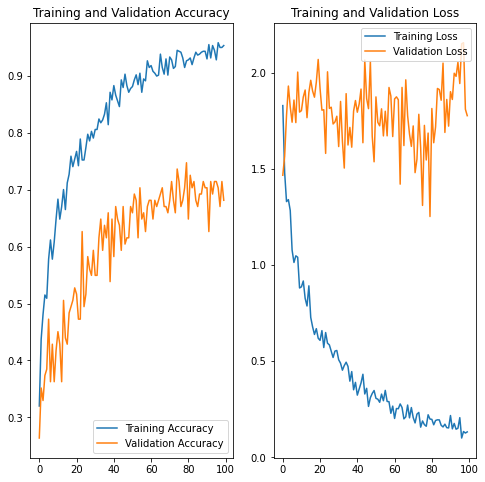

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(100)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

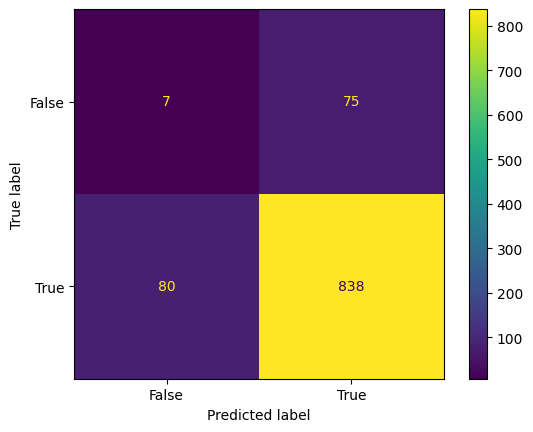

In [ ]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

actual = numpy.random.binomial(1,.9,size = 1000)
predicted = numpy.random.binomial(1,.9,size = 1000)
confusion_matrix = metrics.confusion_matrix(actual, predicted)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

In [ ]:
model.evaluate(train_generator)

77/77 [==============================] - 10s 125ms/step - loss: 0.0162 - accuracy: 0.9951 - auc: 0.9995 - precision: 0.7503 - recall: 1.0000


[0.01617632806301117,
 0.995106041431427,
 0.9995312094688416,
 0.7503060102462769,
 1.0]

In [ ]:
model.evaluate(test_generator)

40/40 [==============================] - 112s 3s/step - loss: 0.5010 - accuracy: 0.8635 - auc: 0.9549 - precision: 0.5267 - recall: 0.9714


[0.5010098218917847,
 0.8634920716285706,
 0.9549391269683838,
 0.5266781449317932,
 0.9714285731315613]

In [ ]:
model.evaluate(validation_generator)

12/12 [==============================] - 1s 119ms/step - loss: 2.1412 - accuracy: 0.6813 - auc: 0.8320 - precision: 0.4706 - recall: 0.7912


[2.1411569118499756,
 0.6813187003135681,
 0.8319848775863647,
 0.47058823704719543,
 0.791208803653717]

In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/Final Year Project/MobileNetV2.h5',model)

In [ ]:
mymodel=load_model('/content/drive/MyDrive/Colab Notebooks/Final Project/Original 5 Models/MobileNetV2.h5')

In [ ]:
mymodel.evaluate(train_generator)

77/77 [==============================] - 11s 131ms/step - loss: 0.0169 - accuracy: 0.9951 - auc: 0.9993 - precision: 0.7577 - recall: 1.0000


[0.016853034496307373,
 0.995106041431427,
 0.9993218183517456,
 0.7577255964279175,
 1.0]

In [ ]:
mymodel.evaluate(test_generator)

40/40 [==============================] - 5s 131ms/step - loss: 0.5280 - accuracy: 0.8635 - auc: 0.9505 - precision: 0.5050 - recall: 0.9556


[0.5280265808105469,
 0.8634920716285706,
 0.9505349397659302,
 0.505033552646637,
 0.9555555582046509]

In [ ]:
mymodel.evaluate(validation_generator)

12/12 [==============================] - 1s 120ms/step - loss: 2.2917 - accuracy: 0.6923 - auc: 0.8309 - precision: 0.4645 - recall: 0.7912


[2.2917239665985107,
 0.692307710647583,
 0.830877959728241,
 0.46451613306999207,
 0.791208803653717]

1/1 [==============================] - 1s 1s/step
[[0.8957554  0.07617089 0.13544597 0.8682142 ]]
THE UPLOADED IMAGE IS SUSPECTED AS: Adenocarcinoma


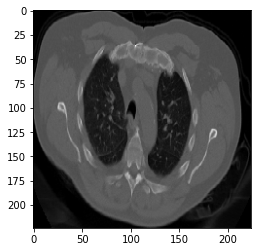

In [ ]:
from keras.preprocessing import image
img = tf.keras.utils.load_img('/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000117 (4).png',target_size=(224,224))
imag = tf.keras.utils.img_to_array(img)
imaga = np.expand_dims(imag,axis=0) 
ypred = model.predict(imaga)
print(ypred)
a=np.argmax(ypred,-1)
if a==0:
  op="Adenocarcinoma"
elif a==1:
  op="large cell carcinoma"
elif a==2:
  op="normal (void of cancer)"
else:
  op="squamous cell carcinoma"    
plt.imshow(img)
print("THE UPLOADED IMAGE IS SUSPECTED AS: "+str(op))  